# Случайный лес (Random Forest)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import r2_score

In [3]:
import warnings
warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 12, 'figure.figsize': (5,4)})
sns.set(style='whitegrid')
sns.set_context("paper", font_scale=1.5)
pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_rows', 50)

Основным недостатком деревьев решений является их склонность к переобучению и тот факт, что даже при небольшом изменении обучающей выборки дерево может значительно измениться. Однако их объединение в ансамбли или композиции на практике дает очень хорошие результаты.

**Ансамбли** - это методы, сочетающие в себе несколько алгоритмов машинного обучения для получения более мощной модели. Одни из самых хорошо зарекомендовавших себя ансамблей при решении задач классификации и регрессии с использованием деревьев решения - это модели **случайный лес** и **градиентный бустинг**.

## Разложение ошибки на смещение и разброс

**Ошибка на новых данных = СМЕЩЕНИЕ^2 + РАЗБРОС + ШУМ,**

где СМЕЩЕНИЕ (bias) - отклонение усредненного ответа обученной модели от ответа идеальной модели;

РАЗБРОС (variance) - дисперсия или разброс ответов обученных моделей относительно среднего ответа;

ШУМ (noise) - ошибка идеальной модели, характеристика входных данных.

Разберем на примерах.

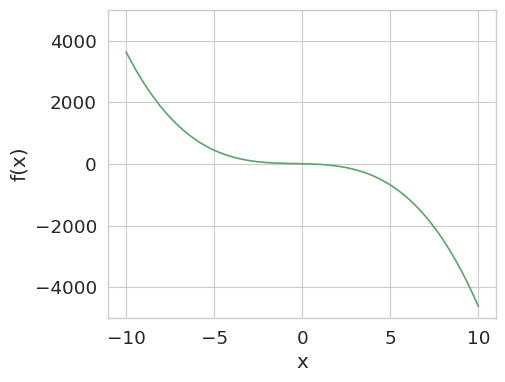

In [4]:
# исходная зависимость
def f(x):
    return 6 - 13 * x - 5 * x ** 2 - 4 * x ** 3

dots = np.linspace(-10, 10, 100)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(-5000, 5000)


plt.plot(dots, f(dots), color='g');

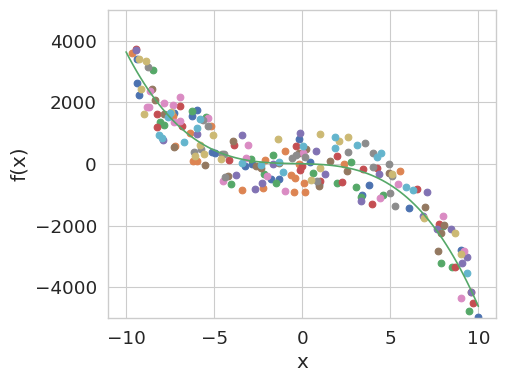

In [5]:
# генерируем данные для 10 моделей
x_datas = []
y_datas = []
for i in range(10):
  x_data = np.random.uniform(-10, 10, 20)
  x_datas.append(x_data)
  y_data = [f(x) for x in x_data] + np.random.uniform(-1000, 1000, 20)
  y_datas.append(y_data)

plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(-5000, 5000)
plt.plot(dots, f(dots), color='g')
for i in range(10):
  plt.scatter(x_datas[i], y_datas[i]);

### Пример модели с высоким смещением (bias) и низким разбросом (variance)

In [6]:
from sklearn.linear_model import LinearRegression

regressors = []
scores = []
for i in range(10):
    # создадим модель
    regressor = LinearRegression()

    # обучим ее
    regressor.fit(np.reshape(x_datas[i], (-1, 1)), y_datas[i])
    #scores.append(regressor.score(np.reshape(x_datas[i], (-1, 1)), y_datas[i]))
    scores.append(regressor.score(np.reshape(dots, (-1, 1)),
                                  f(dots)))
    regressors.append(regressor)
print(f'R2 для LinearRegression = {np.mean(scores):.2}')

R2 для LinearRegression = 0.78


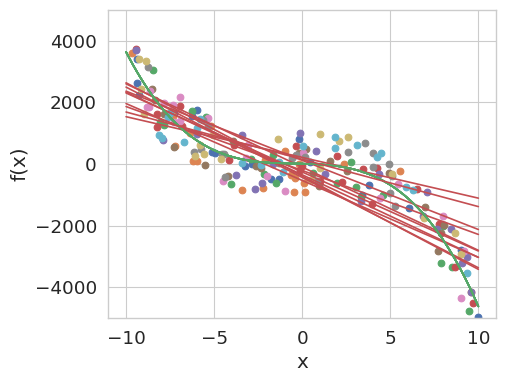

In [7]:
plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(-5000, 5000)

predictions = []
for i in range(10):
    plt.plot(dots, f(dots), color='g')
    plt.scatter(x_datas[i], y_datas[i])
    pred = regressors[i].predict(np.reshape(dots, (-1, 1)))
    predictions.append(pred)
    plt.plot(dots, pred, color='r');
predictions = np.array(predictions)

R2 для 10 линейных регрессий = 0.84


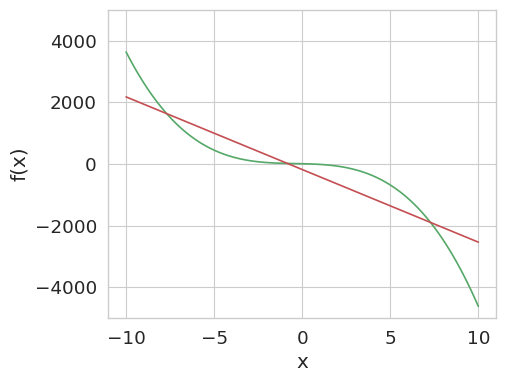

In [8]:
mean_prediction = np.mean(predictions, axis=0)
print(f'R2 для 10 линейных регрессий = {r2_score(f(dots), mean_prediction):.2}')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(-5000, 5000)

plt.plot(dots, f(dots), color='g')
plt.plot(dots, mean_prediction, color='r');

### Пример модели с низким смещением (bias) и высоким разбросом (variance)

In [9]:
from sklearn.tree import DecisionTreeRegressor

regressors = []
scores = []
for i in range(10):
    # создадим модель
    regressor = DecisionTreeRegressor(random_state=42, max_depth=10)
    # обучим ее
    regressor.fit(np.reshape(x_datas[i], (-1, 1)), y_datas[i])
    #scores.append(regressor.score(np.reshape(x_datas[i], (-1, 1)), y_datas[i]))
    scores.append(regressor.score(np.reshape(dots, (-1, 1)),
                                  f(dots)))
    regressors.append(regressor)
print(f'R2 для DecisionTreeRegressor = {np.mean(scores):.2}')

R2 для DecisionTreeRegressor = 0.8


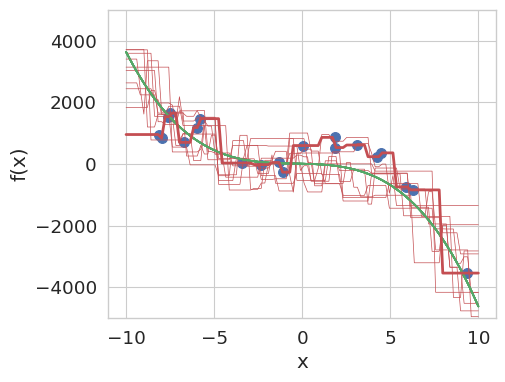

In [10]:
plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(-5000, 5000)

predictions = []
for i in range(10):
    plt.plot(dots, f(dots), color='g')
    #plt.scatter(x_datas[i], y_datas[i])
    pred = regressors[i].predict(np.reshape(dots, (-1, 1)))
    predictions.append(pred)
    plt.plot(dots, pred, color='r', linewidth=0.5);
predictions = np.array(predictions)
plt.scatter(x_datas[-1], y_datas[-1], s=50)
plt.plot(dots, pred, color='r', linewidth=2);

R2 для 10 деревьев решений = 0.97


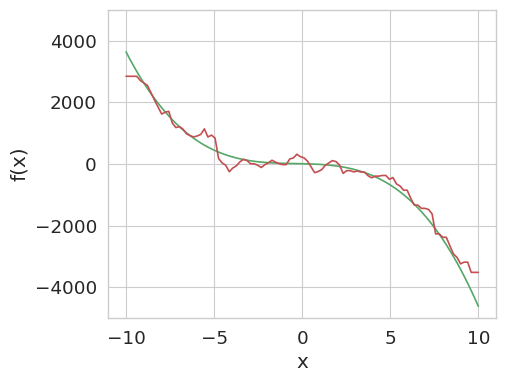

In [11]:
mean_prediction = np.mean(predictions, axis=0)
print(f'R2 для 10 деревьев решений = {r2_score(f(dots), mean_prediction):.2}')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.ylim(-5000, 5000)

plt.plot(dots, f(dots), color='g')
plt.plot(dots, mean_prediction, color='r');

Когда собираем *N* базовых алгоритмов в ансамбль, то в целом у ансамбля:

* СМЕЩЕНИЕ не изменится
* ШУМ не изменится
* РАЗБРОС = (РАЗБРОС базового алгоритма) / *N* + корреляция между базовыми алгоритмами

Способы уменьшения корреляции:

- *бэггинг (bagging)* - обучение базовых алгоритмов на случайной подвыборке
- *метод случайных подпространств* - обучение базовых алгоритмов на случайном подмножестве признаков

### Бутстрап

Бутстрап (bootstrap) - один из способов построения случайных подвыборок. Для получения бутстрап-выборки из исходной выборки размера *n* выбирается случайный элемент *n* раз, причем каждый раз новый элемент выбирается из всей выборки. Таким образом, в полученной бутстрап-выборке некоторые элементы исходной выборки будут встречаться несколько раз, а некоторые (примерно 37% выборки) будут вовсе отсутствовать, и при повторении 𝑁 раз мы получим 𝑁 разных выборок длиной *n*.

In [12]:
# Bagging = Bootstrap aggregating
'''
X = [1, 2, 3, 4, 5]

X1 = [2, 4, 2, 4, 1] # tree_1.fit(X1, y)
X2 = [1, 3, 2, 3, 2] # tree_2.fit(X2, y)
X3 = [2, 4, 5, 5, 5] # tree_3.fit(X3, y)

tree_1.predict(6, 7, 8, 9) # 1, 0, 0, 0
tree_2.predict(6, 7, 8, 9) # 1, 1, 1, 0
tree_3.predict(6, 7, 8, 9) # 0, 1, 0, 0
'''
# прогноз ансамбля: 1, 1, 0, 0
#
# OOB
'''
tree_1.predict(3, 5) # 1, 0
tree_2.predict(4, 5) # 1, 0
tree_3.predict(1, 3) # 1, 0
'''
# 1 - 1, 2 - None, 3 - 1, 4 - 1, 5 - 0

'\ntree_1.predict(3, 5) # 1, 0\ntree_2.predict(4, 5) # 1, 0\ntree_3.predict(1, 3) # 1, 0\n'

### Метод случайных подпространств

Для уменьшения корреляции базовых алгоритмов (деревьев решений) условие в каждом узле выбирается не из всего пространства признаков, а из его случайного подмножества размера $m$.

Есть некоторые практические рекомендации по построению случайных лесов: в задачах классификации рекомендуется брать $m=\sqrt{d}$, где $d$ - общее число признаков, и строить дерево до тех пор, пока в каждом листе не останется по одному объекту, а в задаче регрессии принимать $m=d/3$ и строить дерево, пока в листьях не останется по пять объектов.

### Out-of-bag (OOB) error

Каждое дерево, составляющее случайный лес, строится на основе бутстрап-выборки. При этом примерно 37% объектов не попадают в эту выборку, и дерево на них не обучается. Эти объекты можно использовать для оценки качества полученного алгоритма, это и называется **out-of-bag error**. Для каждого OOB объекта мы можем найти деревья, которые на нем не обучались, и вычислить ошибку. Она рассчитывается как сумма значений ошибки для среднего ответа на каждом объекте среди деревьев, которые на нем не обучались.

Таким образом, при этом методе оценивания качества исчезает необходимость использовать отложенные выборки и кросс-валидацию при обучении случайных лесов.

## Генерация данных

Сформируем с помощью `sklearn.make_classification` датасет из 1000 объектов с двумя признаками.

In [13]:
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000,
                           n_features=2, n_informative=2,
                           n_classes=2, n_redundant=0,
                           n_clusters_per_class=2, flip_y=0.1, random_state=1)

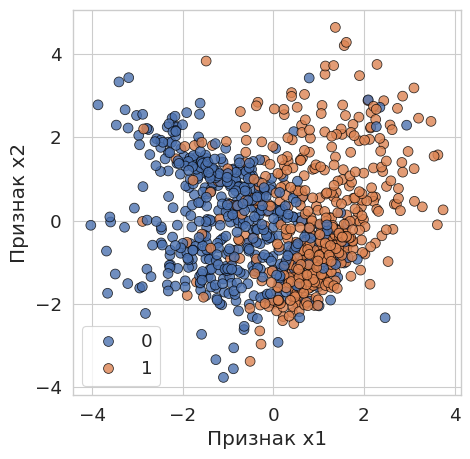

In [14]:
# визуализируем сгенерированные данные
plt.figure(figsize=(5,5))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, s=50, alpha=0.8,
               edgecolor='black')
plt.xlabel('Признак x1')
plt.ylabel('Признак x2');

## Создание отложенной выборки

Сделаем выборку данных 25% для проверки качества предсказания.

In [15]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.25, random_state=42)
X_train.shape, X_valid.shape

((750, 2), (250, 2))

## Построение модели Random Forest (Случайный лес)

**Случайный лес** - это множество решающих деревьев. Все деревья строятся независимо друг от друга на разных выборках обучающего датасета и с использованием разных признаков.

![](https://drive.google.com/uc?export=view&id=1PDdkWXfH3ZKBmfwqQIxJy_CB1ee0Od9g)

На картинке выше случайный лес из четырех деревьев решений голосованием решает какой класс присвоить новому объекту. В задачах регрессии ответом ансамбля будет среднее арифметическое всех предсказаний деревьев.

In [16]:
from sklearn.ensemble import RandomForestClassifier

RandomForestClassifier().get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

Обучим случайный лес из 10 деревьев.

In [17]:
forest = RandomForestClassifier(n_estimators=10, random_state=42)
forest.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=42)

In [18]:
y_train_pred = forest.predict(X_train) # получим прогнозы
print(f'Accuracy на обучающей выборке = {forest.score(X_train, y_train):.3}')

Accuracy на обучающей выборке = 0.98


Проверим точность модели на отложенной выборке.

In [19]:
y_pred = forest.predict(X_valid) # получим прогнозы
print(f'Accuracy на отложенной выборке = {forest.score(X_valid, y_valid):.3}')

Accuracy на отложенной выборке = 0.752


### Основные параметры случайного леса


* `n_estimators` – число деревьев в лесу
* `max_depth` – максимальная глубина дерева
* `max_features` – максимальное число признаков, по которым ищется лучшее разбиение в дереве
* `min_samples_leaf` – минимальное число объектов в листе
* `min_samples_split` – минимальное количество объектов, необходимое для разделения в узле
* `oob_score` - оценивать ли точность модели на OOB объектах

### Подбор гиперпараметров случайного леса

Чем больше деревьев, тем лучше качество, но время обучения также пропорционально увеличиваются. Подберем теперь значение параметра `max_depth`. Чем меньше глубина, тем быстрее работает случайный лес, но качество при этом может пострадать.

In [20]:
forest = RandomForestClassifier(n_estimators=10,
                               max_depth=4,
                               random_state=42)
forest.fit(X_train, y_train) # обучим модель
y_pred = forest.predict(X_valid) # получим прогнозы
print(f'Accuracy на отложенной выборке = {forest.score(X_valid, y_valid):.3}')

Accuracy на отложенной выборке = 0.816


При увеличении `max_features` увеличивается время построения леса, а деревья становятся более одинаковыми, что плохо сказывается на точности.

In [21]:
forest = RandomForestClassifier(n_estimators=10,
                               max_features=2,
                               random_state=42)
forest.fit(X_train, y_train) # обучим модель
y_pred = forest.predict(X_valid) # получим прогнозы
print(f'Accuracy на отложенной выборке = {forest.score(X_valid, y_valid):.3}')

Accuracy на отложенной выборке = 0.772


По умолчанию минимальное число объектов в листе `min_samples_leaf`=1. При увеличении параметра качество на train может упасть, а на новых данных вырасти (таким образом боремся с переобучением), время построения леса сокращается.

In [22]:
forest = RandomForestClassifier(n_estimators=10,
                               min_samples_leaf=5,
                               random_state=42)
forest.fit(X_train, y_train) # обучим модель
y_pred = forest.predict(X_valid) # получим прогнозы
print(f'Accuracy на отложенной выборке = {forest.score(X_valid, y_valid):.3}')

Accuracy на отложенной выборке = 0.812


Параметр `n_estimators` задает количество деревьев в ансамбле. По умолчанию равен 100. Увеличим количество деревьев и проверим точность случайного леса на OOB объектах.

In [23]:
forest = RandomForestClassifier(n_estimators=100,
                               random_state=42,
                               oob_score=True)
forest.fit(X, y) # обучим модель на всех данных
print(f'Accuracy на OOB объектах = {forest.oob_score_:.3}')

Accuracy на OOB объектах = 0.82


Посмотрим на важность признаков.

In [24]:
importance_rf = forest.feature_importances_
importance_rf

array([0.70596163, 0.29403837])

Визуализируем случайный лес.

In [25]:
def get_grid(data):
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
    return np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

def forest_viz(model, train_data, train_labels, test_data, test_labels, trees):
    figure, axes = plt.subplots(nrows=1, ncols=2, sharex=True, figsize=(12, 5))
    xx, yy = get_grid(train_data)

    ax = axes[0]
    predicted = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.pcolormesh(xx, yy, predicted, cmap='Set3', alpha=0.9)
    sns.scatterplot(x=train_data[:, 0], y=train_data[:, 1],
                    hue=train_labels, s=50, edgecolor='black', legend=None, ax=ax)
    ax.set_title('TRAIN, {} trees, accuracy = {:.3f}'.format(
                    trees, forest.score(train_data, train_labels)))

    ax = axes[1]
    ax.pcolormesh(xx, yy, predicted, cmap='Set3', alpha=0.9)
    sns.scatterplot(x=test_data[:, 0], y=test_data[:, 1],
                    hue=test_labels, s=50, edgecolor='black', legend=None, ax=ax)
    ax.set_title('TEST, {} trees, accuracy = {:.3f}'.format(
                    trees, forest.score(test_data, test_labels)))

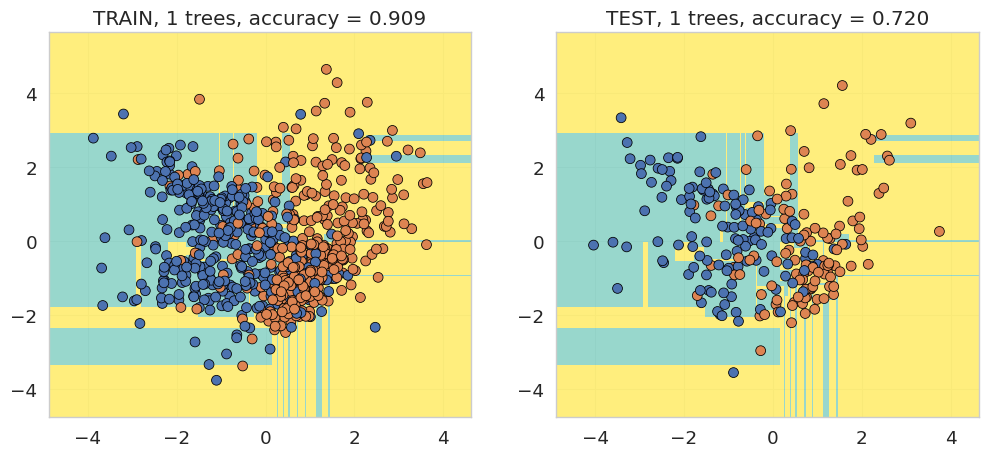

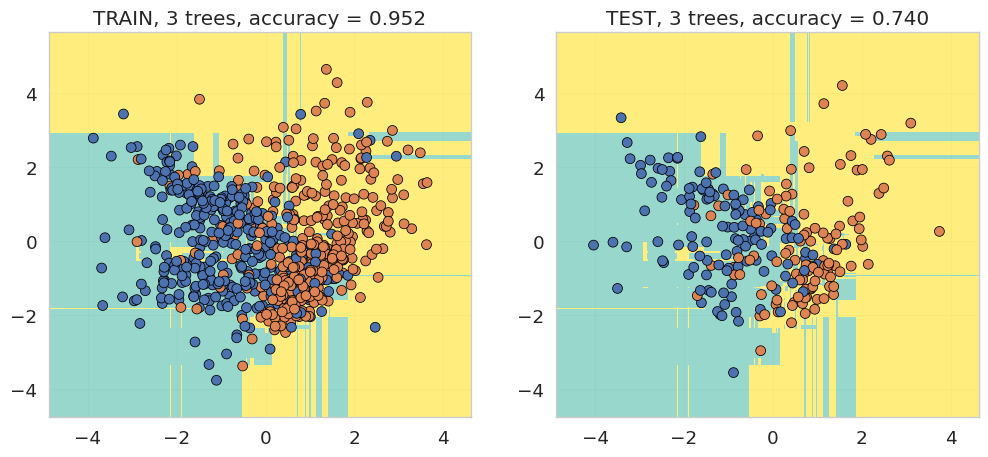

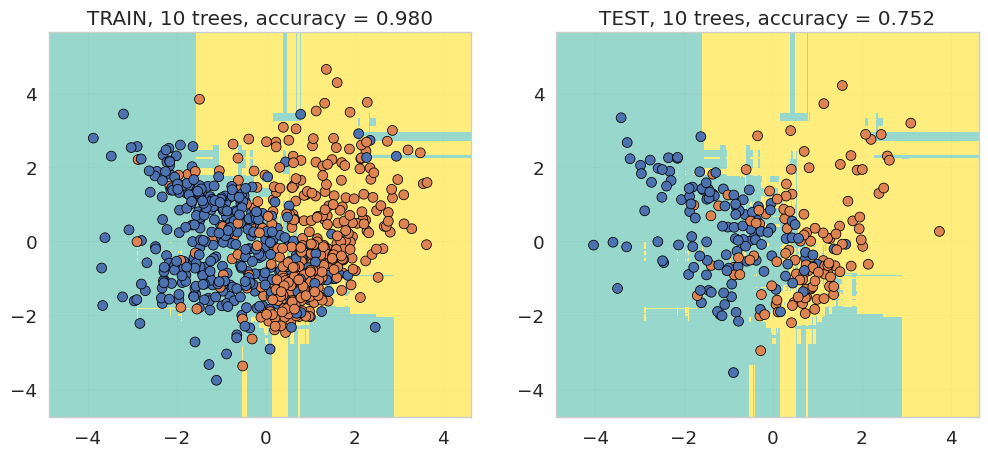

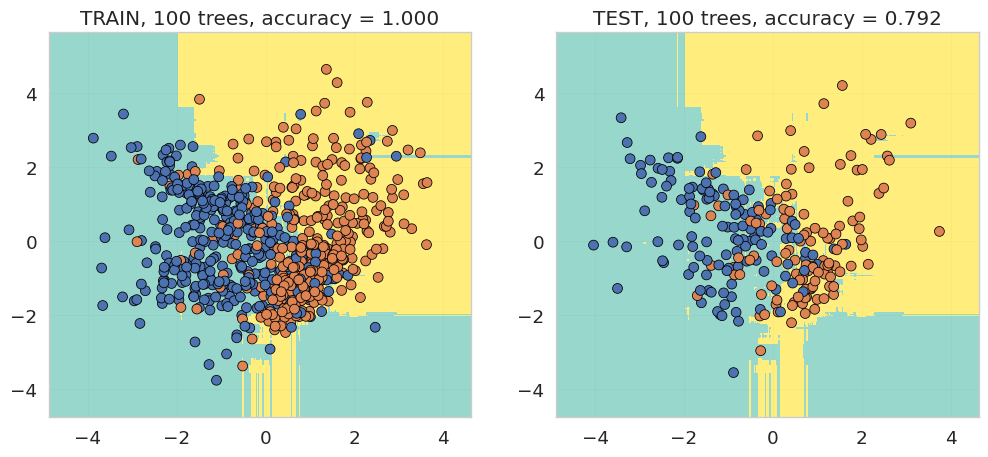

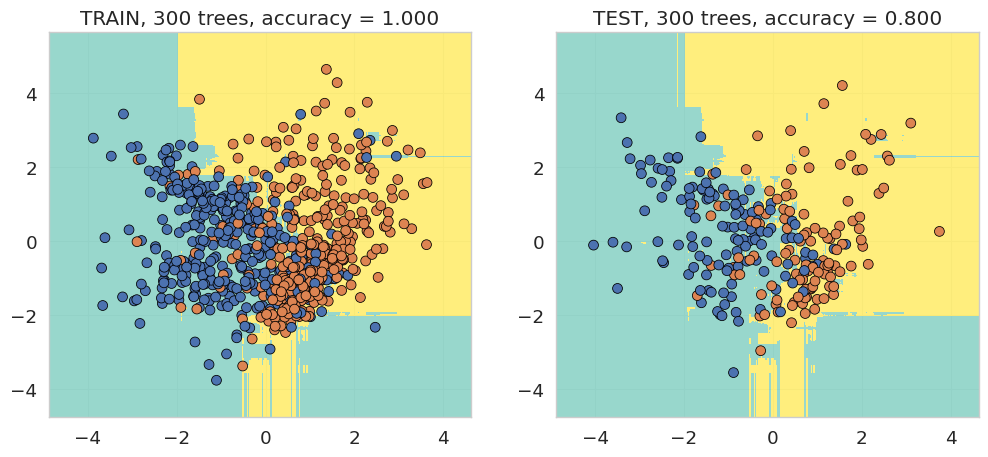

In [26]:
tree_numbers = (1, 3, 10, 100, 300)
for trees in tree_numbers:
  forest = RandomForestClassifier(n_estimators=trees,
                                  random_state=42)
  forest.fit(X_train, y_train)
  forest_viz(forest, X_train, y_train, X_valid, y_valid, trees)

Если наблюдается большая разница между метриками на трейне и на тесте, и она растет с увеличением количества деревьев, то это свидетельствует о **переобучении** модели. Случайный лес считается довольно устойчивым к переобучению.

Рассматриваемый случайный лес построен без ограничений на рост древьев решений, но разница между метриками при увеличении количества деревьев не растет, значит про переобучение этой модели говорить рано.



## Дополнительный материал

[Understanding the Bias-Variance Tradeoff](http://scott.fortmann-roe.com/docs/BiasVariance.html)

[RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

## Задания

1. Постройте на одном графике зависимости точности случайного леса на обучающей и отложенной выборке от количества деревьев (до 1000 деревьев) (3 балла).

In [27]:
# код

2. Загрузите датасет `prepared.csv`. Выполните следующее (9 баллов):

- Выделите отдельно матрицу с признаками `X` (это датасет `df` без столбцов `'Id'`, `'Price'` и `'PriceOneRoom'`) и массив с ответами `y = df['Price']`.
- Разбейте данные на train и valid.  
- Обучите модель случайного леса `RandomForestRegressor` на обучающей выборке (train).
- Проверьте точность модели на валидационной выборке (valid).
- Найдите самые важные для случайного леса признаки.  
- Подберите такие гиперпараметры модели, чтобы коэффициент детерминации R2 был больше 0.73.

**Описание датасета**

* **Id** - идентификационный номер квартиры
* **DistrictId** - идентификационный номер района
* **Rooms** - количество комнат
* **Square** - площадь
* **LifeSquare** - жилая площадь
* **KitchenSquare** - площадь кухни
* **Floor** - этаж
* **HouseFloor** - количество этажей в доме
* **HouseYear** - год постройки дома
* **Ecology_1, Ecology_2, Ecology_3** - экологические показатели местности
* **Social_1, Social_2, Social_3** - социальные показатели местности
* **Helthcare_2** - показатели местности, связанные с охраной здоровья
* **Shops_1, Shops_2** - показатели, связанные с наличием магазинов, торговых центров
* **Price** - цена квартиры - **целевая переменная**
* **PriceOneRoomByDistrict** - средняя цена одной комнаты по районам
* **Floor_cat** - категория этажа

In [28]:
!gdown 1WonVHHMWLsLLE9sdKKTKPA-WfZTUUEra
df = pd.read_csv('/content/prepared.csv', index_col=0)

Downloading...
From: https://drive.google.com/uc?id=1WonVHHMWLsLLE9sdKKTKPA-WfZTUUEra
To: /content/prepared.csv
100% 1.64M/1.64M [00:00<00:00, 18.3MB/s]


In [29]:
df.head()

,Id,DistrictId,Rooms,Square,LifeSquare,KitchenSquare,Floor,HouseFloor,HouseYear,Ecology_1,...,Social_1,Social_2,Social_3,Helthcare_2,Shops_1,Shops_2,Price,PriceOneRoom,PriceOneRoomByDistrict,Floor_cat
0,14038,35,2.00,47.98,29.44,6.00,7.00,9.00,1969,0.09,...,33,7976,5,0,11,1,"184,966.93","92,483.47","121,239.81",2.00
1,15053,41,3.00,65.68,40.05,8.00,7.00,9.00,1978,0.00,...,46,10309,1,1,16,1,"300,009.45","100,003.15","120,688.95",2.00
2,4765,53,2.00,44.95,29.20,0.00,8.00,12.00,1968,0.05,...,34,7759,0,1,3,1,"220,925.91","110,462.95","138,669.20",2.00
3,5809,58,2.00,53.35,52.73,9.00,8.00,17.00,1977,0.44,...,23,5735,3,0,5,1,"175,616.23","87,808.11","105,638.52",2.00
4,10783,99,1.00,39.65,23.78,7.00,11.00,12.00,1976,0.01,...,35,5776,1,2,4,1,"150,226.53","150,226.53","101,817.58",2.00


In [30]:
# код